 # Лабораторна робота 10.3 (Extended Experiments)

 **Датасет:** 2000 train, 500 val, 500 test (per class).

 ## Підготовка даних (Setup)

In [2]:
import os
import random
import shutil
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Завантаження даних
if not os.path.exists("cats_dogs.zip"):
    !curl -L -o ./cats_dogs.zip https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset
    !unzip -q cats_dogs.zip

# Підготовка директорій
base_dir = "./PetImages_Lab10"
if os.path.exists(base_dir):
    shutil.rmtree(base_dir)
os.mkdir(base_dir)

dirs = ["training", "validation", "testing"]
classes = ["cats", "dogs"]

for d in dirs:
    os.makedirs(os.path.join(base_dir, d), exist_ok=True)
    for c in classes:
        os.makedirs(os.path.join(base_dir, d, c), exist_ok=True)


# Функція спліту (2000 / 500 / 500)
def split_data(
    SOURCE, TRAINING, VALIDATION, TESTING, TRAIN_SIZE=2000, VAL_SIZE=500, TEST_SIZE=500
):
    files = [
        f for f in os.listdir(SOURCE) if os.path.getsize(os.path.join(SOURCE, f)) > 0
    ]

    if len(files) < (TRAIN_SIZE + VAL_SIZE + TEST_SIZE):
        print(f"Not enough images in {SOURCE}")
        return

    random.sample(files, len(files))  # Shuffle
    random.shuffle(files)

    train_files = files[:TRAIN_SIZE]
    val_files = files[TRAIN_SIZE : TRAIN_SIZE + VAL_SIZE]
    test_files = files[TRAIN_SIZE + VAL_SIZE : TRAIN_SIZE + VAL_SIZE + TEST_SIZE]

    for f in train_files:
        shutil.copyfile(os.path.join(SOURCE, f), os.path.join(TRAINING, f))
    for f in val_files:
        shutil.copyfile(os.path.join(SOURCE, f), os.path.join(VALIDATION, f))
    for f in test_files:
        shutil.copyfile(os.path.join(SOURCE, f), os.path.join(TESTING, f))


split_data(
    "./PetImages/Cat/",
    f"{base_dir}/training/cats",
    f"{base_dir}/validation/cats",
    f"{base_dir}/testing/cats",
)
split_data(
    "./PetImages/Dog/",
    f"{base_dir}/training/dogs",
    f"{base_dir}/validation/dogs",
    f"{base_dir}/testing/dogs",
)

print("Data processing complete.")


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  775M  100  775M    0     0  21.2M      0  0:00:36  0:00:36 --:--:-- 23.2M
Data processing complete.


 ## Універсальна функція для експериментів

In [3]:
def run_experiment(name, base_model_class, target_size, preprocess_func, 
                   dropout_rate, unfreeze_from_layer_name=None, 
                   augment_type='standard', optimizer_type='rmsprop'):
    
    print(f"\n{'='*20}\nSTARTING EXPERIMENT: {name}\n{'='*20}")
    
    # 1. Налаштування аугментації
    if augment_type == 'standard':
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_func,
            rotation_range=30, width_shift_range=0.2, height_shift_range=0.2,
            shear_range=0.2, zoom_range=0.2, horizontal_flip=True, fill_mode='nearest'
        )
    elif augment_type == 'strong':
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_func,
            rotation_range=40, width_shift_range=0.2, height_shift_range=0.2,
            shear_range=0.2, zoom_range=0.3, horizontal_flip=True, 
            brightness_range=[0.7, 1.3], channel_shift_range=20.0, fill_mode='nearest'
        )
        
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    train_gen = train_datagen.flow_from_directory(
        f"{base_dir}/training", target_size=target_size, batch_size=32, class_mode='binary'
    )
    val_gen = test_datagen.flow_from_directory(
        f"{base_dir}/validation", target_size=target_size, batch_size=32, class_mode='binary'
    )
    test_gen = test_datagen.flow_from_directory(
        f"{base_dir}/testing", target_size=target_size, batch_size=32, class_mode='binary', shuffle=False
    )

    # 2. Побудова моделі (Feature Extraction)
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=target_size+(3,))
    base_model.trainable = False
    
    x = base_model.output
    # Використовуємо GlobalAveragePooling для сучасних моделей, Flatten для VGG (історично)
    if 'VGG' in name:
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
    else:
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(512, activation='relu')(x)
        
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=base_model.input, outputs=outputs)

    # Вибір оптимізатора
    if optimizer_type == 'adam':
        opt = optimizers.Adam(learning_rate=0.001)
    else:
        opt = optimizers.RMSprop(learning_rate=0.0001)

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    
    print(f"--- Phase 1: Training Head ({name}) ---")
    hist_phase1 = model.fit(train_gen, epochs=6, validation_data=val_gen, verbose=1)

    # 3. Fine Tuning
    if unfreeze_from_layer_name:
        print(f"--- Phase 2: Fine Tuning ({name}) ---")
        base_model.trainable = True
        set_trainable = False
        
        # Логіка розморожування
        for layer in base_model.layers:
            if layer.name == unfreeze_from_layer_name:
                set_trainable = True
            if set_trainable:
                # Для ResNet не розморожуємо BatchNormalization шари (це важливо!)
                if 'BatchNormalization' in layer.__class__.__name__:
                    layer.trainable = False
                else:
                    layer.trainable = True
            else:
                layer.trainable = False
        
        # Компілюємо з низьким LR
        model.compile(
            optimizer=optimizers.RMSprop(learning_rate=1e-5), # Low LR is key
            loss='binary_crossentropy', 
            metrics=['accuracy']
        )
        
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)
        ]

        hist_phase2 = model.fit(train_gen, epochs=15, validation_data=val_gen, callbacks=callbacks, verbose=1)
        
        # Об'єднуємо історію для графіка
        for k in hist_phase1.history.keys():
            hist_phase1.history[k].extend(hist_phase2.history[k])

    # 4. Оцінка
    print(f"--- Evaluating ({name}) ---")
    loss, acc = model.evaluate(test_gen)
    print(f"Test Accuracy: {acc*100:.2f}%")

    return hist_phase1, acc


In [8]:

experiment_results = []

def analyze_and_store_results(name, history, accuracy):
    """Візуалізує результати одного експерименту та зберігає їх."""
    print(f"\n--- Результати для: {name} ---")

    # 1. Візуалізація історії
    plt.figure(figsize=(12, 5))
    
    # Графік точності
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy for {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Графік втрат
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss for {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    # 2. Вивід таблиці результатів
    print("\n" + "="*50)
    print(f"{'EXPERIMENT NAME':<30} | {'TEST ACCURACY':<10}")
    print("-" * 50)
    print(f"{name:<30} | {accuracy*100:.2f}%")
    print("="*50 + "\n")

    # 3. Збереження результатів для фінального порівняння
    experiment_results.append({
        'title': name,
        'history': history,
        'accuracy': accuracy
    })

 ## Експеримент 1: VGG16 (Shallow Fine-Tuning)

 *   **Параметри:** Dropout 0.5 (з Lab 08), RMSprop.

 *   **FT:** Розморожуємо тільки останній **block5_conv1**.

In [14]:
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg_prep

hist_vgg_shallow, acc_vgg_shallow = run_experiment(
    name="Exp 1: VGG16 Shallow FT",
    base_model_class=VGG16,
    target_size=(150, 150),
    preprocess_func=vgg_prep,
    dropout_rate=0.5,
    unfreeze_from_layer_name='block5_conv1'
)


STARTING EXPERIMENT: Exp 1: VGG16 Shallow FT
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
--- Phase 1: Training Head (Exp 1: VGG16 Shallow FT) ---
Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 53s 330ms/step - accuracy: 0.7734 - loss: 3.9172 - val_accuracy: 0.9480 - val_loss: 0.6798
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.9029 - loss: 1.0348 - val_accuracy: 0.9630 - val_loss: 0.2372
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 267ms/step - accuracy: 0.9238 - loss: 0.5881 - val_accuracy: 0.9690 - val_loss: 0.2418
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 271ms/step - accuracy: 0.9420 - loss: 0.4981 - val_accuracy: 0.9700 - val_loss: 0.1943
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.9356 - loss: 0.4573 - val_accuracy: 0.9730 - val_loss: 0.1793
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.94


--- Результати для: VGG Shallow ---


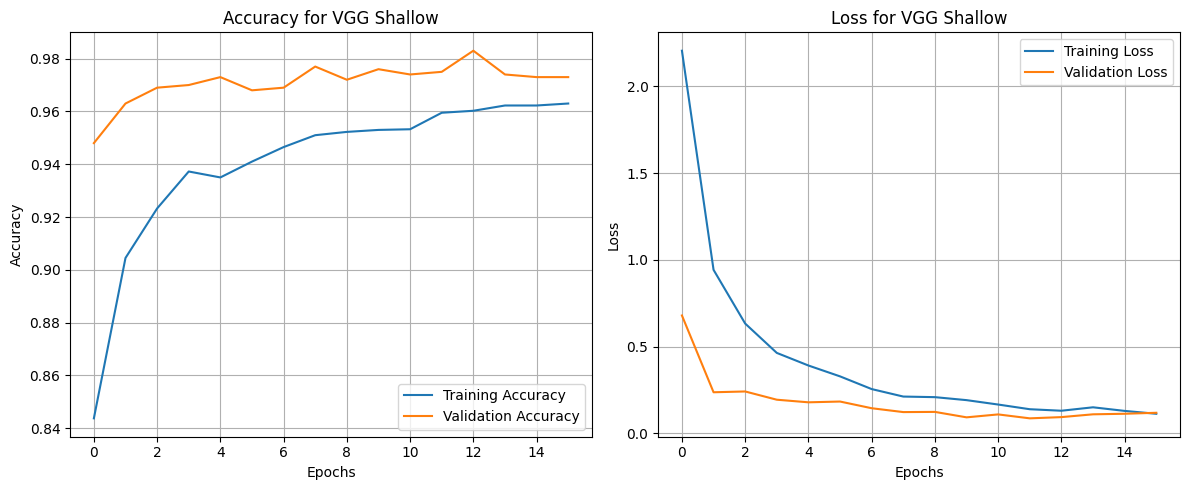


EXPERIMENT NAME                | TEST ACCURACY
--------------------------------------------------
VGG Shallow                    | 97.50%



In [15]:
analyze_and_store_results("VGG Shallow", hist_vgg_shallow, acc_vgg_shallow)

 ## Експеримент 2: VGG16 (Deep Fine-Tuning)

 *   **Параметри:** Ті самі, що в Експ 1.

 *   **FT:** Розморожуємо глибше -> з **block4_conv1**. Це дозволить моделі змінити уявлення про більш абстрактні форми, а не тільки деталі.

In [17]:
hist_vgg_deep, acc_vgg_deep = run_experiment(
    name="Exp 2: VGG16 Deep FT",
    base_model_class=VGG16,
    target_size=(150, 150),
    preprocess_func=vgg_prep,
    dropout_rate=0.5,
    unfreeze_from_layer_name='block4_conv1'
)


STARTING EXPERIMENT: Exp 2: VGG16 Deep FT
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
--- Phase 1: Training Head (Exp 2: VGG16 Deep FT) ---
Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 280ms/step - accuracy: 0.7867 - loss: 3.3889 - val_accuracy: 0.9600 - val_loss: 0.4205
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.9212 - loss: 0.6983 - val_accuracy: 0.9520 - val_loss: 0.4459
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.9262 - loss: 0.6600 - val_accuracy: 0.9720 - val_loss: 0.1975
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 274ms/step - accuracy: 0.9336 - loss: 0.4353 - val_accuracy: 0.9670 - val_loss: 0.1922
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 35s 282ms/step - accuracy: 0.9357 - loss: 0.3324 - val_accuracy: 0.9690 - val_loss: 0.1731
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.9341 - loss: 0.3312 - val_accuracy: 0.9690 - val_loss: 0.20


--- Результати для: VGG Deep ---


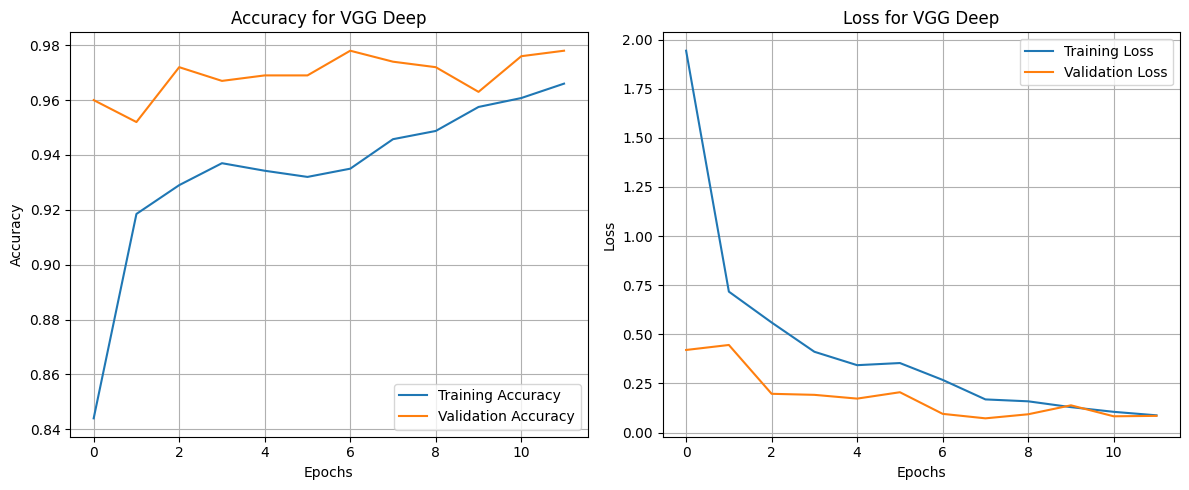


EXPERIMENT NAME                | TEST ACCURACY
--------------------------------------------------
VGG Deep                       | 97.20%



In [18]:
analyze_and_store_results("VGG Deep", hist_vgg_deep, acc_vgg_deep)

 ## Експеримент 3: InceptionV3 (Standard)

 *   **Параметри:** Dropout 0.2 (показав себе найкраще в Lab 08 для цієї моделі).

 *   **FT:** Розморожуємо з шару `mixed7` (стандартна практика для Inception).

In [ ]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input as inc_prep

hist_inc_std, acc_inc_std = run_experiment(
    name="Exp 3: InceptionV3 Standard",
    base_model_class=InceptionV3,
    target_size=(150, 150),
    preprocess_func=inc_prep,
    dropout_rate=0.2,
    unfreeze_from_layer_name='mixed7' 
)



STARTING EXPERIMENT: Exp 3: InceptionV3 Standard
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
--- Phase 1: Training Head (Exp 3: InceptionV3 Standard) ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6
 91/125 ━━━━━━━━━━━━━━━━━━━━ 7s 217ms/step - accuracy: 0.8162 - loss: 0.5616

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 324ms/step - accuracy: 0.8341 - loss: 0.4931 - val_accuracy: 0.9600 - val_loss: 0.1083
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 227ms/step - accuracy: 0.9305 - loss: 0.1743 - val_accuracy: 0.9650 - val_loss: 0.0841
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 225ms/step - accuracy: 0.9449 - loss: 0.1482 - val_accuracy: 0.9580 - val_loss: 0.1006
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 240ms/step - accuracy: 0.9532 - loss: 0.1267 - val_accuracy: 0.9650 - val_loss: 0.0775
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 226ms/step - accuracy: 0.9393 - loss: 0.1453 - val_accuracy: 0.9700 - val_loss: 0.0843
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 231ms/step - accuracy: 0.9448 - loss: 0.1456 - val_accuracy: 0.9650 - val_loss: 0.0807
--- Phase 2: Fine Tuning (Exp 3: InceptionV3 Standard) ---
Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 314ms/step - accuracy: 0.9525 - loss: 0.1230 - val_accuracy: 0.9710 - val_loss: 0.0747 - learning_rate: 1.0000e-05
Epoch 2/15
1


--- Результати для: Inception Std ---


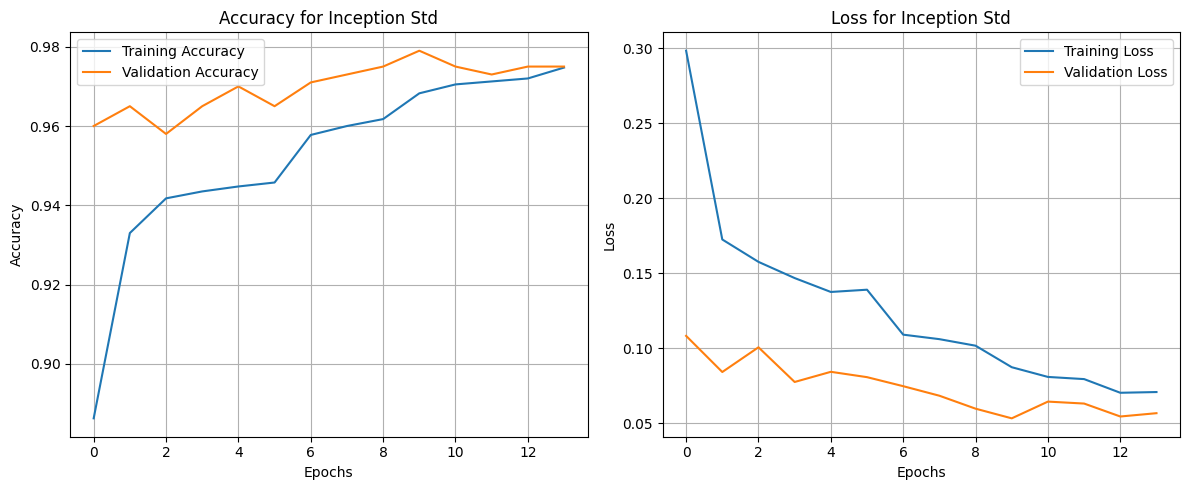


EXPERIMENT NAME                | TEST ACCURACY
--------------------------------------------------
Inception Std                  | 98.20%



In [9]:

analyze_and_store_results("Inception Std", hist_inc_std, acc_inc_std)

 ## Експеримент 4: InceptionV3 (Strong Augmentation)

 *   **Гіпотеза:** Inception — дуже потужна модель. Можливо, стандартна аугментація для неї занадто проста, і вона перенавчається?

 *   **Зміни:** Додаємо `brightness_range` та сильніший зум.

In [ ]:
hist_inc_aug, acc_inc_aug = run_experiment(
    name="Exp 4: InceptionV3 Strong Aug",
    base_model_class=InceptionV3,
    target_size=(150, 150),
    preprocess_func=inc_prep,
    dropout_rate=0.2,
    unfreeze_from_layer_name='mixed7',
    augment_type='strong'
)




STARTING EXPERIMENT: Exp 4: InceptionV3 Strong Aug
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
--- Phase 1: Training Head (Exp 4: InceptionV3 Strong Aug) ---
Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 54s 341ms/step - accuracy: 0.8216 - loss: 0.4322 - val_accuracy: 0.9410 - val_loss: 0.1758
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.9214 - loss: 0.2054 - val_accuracy: 0.9680 - val_loss: 0.0880
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - accuracy: 0.9147 - loss: 0.2112 - val_accuracy: 0.9720 - val_loss: 0.0813
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 269ms/step - accuracy: 0.9196 - loss: 0.1976 - val_accuracy: 0.9670 - val_loss: 0.0839
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.9324 - loss: 0.1653 - val_accuracy: 0.9690 - val_loss: 0.0763
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 34s 268ms/step - accuracy: 0.9388 - loss: 0.1665 - val_accuracy: 0.970


--- Результати для: Inception Aug ---


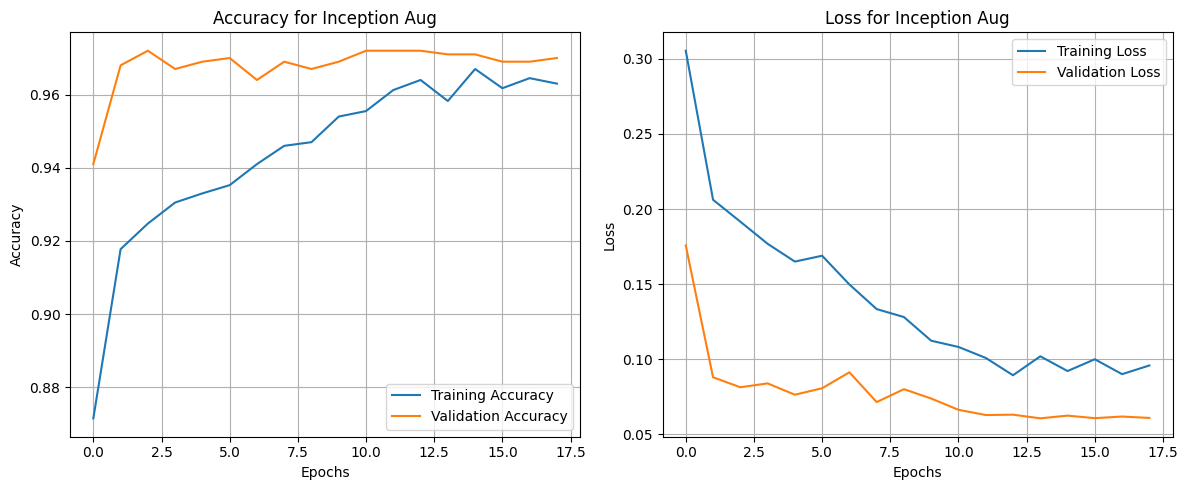


EXPERIMENT NAME                | TEST ACCURACY
--------------------------------------------------
Inception Aug                  | 97.80%



In [10]:
analyze_and_store_results("Inception Aug", hist_inc_aug, acc_inc_aug)

 ## Експеримент 5: ResNet50V2 (Adam Optimizer)

 *   **Модель:** ResNet50**V2** (має кращу збіжність при FT ніж V1).

 *   **Зміни:** Використовуємо оптимізатор **Adam** замість RMSprop для етапу Feature Extraction. Adam часто дає швидший старт.

 *   **FT:** Розморожуємо останній блок `conv5_block1_preact_bn`.

In [7]:
from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input as res_prep

hist_res_adam, acc_res_adam = run_experiment(
    name="Exp 5: ResNet50V2 Adam",
    base_model_class=ResNet50V2,
    target_size=(150, 150),
    preprocess_func=res_prep,
    dropout_rate=0.2,
    unfreeze_from_layer_name='conv5_block1_preact_bn',
    optimizer_type='adam'
)

analyze_and_store_results("ResNet Adam", hist_res_adam, acc_res_adam)



STARTING EXPERIMENT: Exp 5: ResNet50V2 Adam
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
--- Phase 1: Training Head (Exp 5: ResNet50V2 Adam) ---
Epoch 1/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 294ms/step - accuracy: 0.8765 - loss: 0.3886 - val_accuracy: 0.9600 - val_loss: 0.1028
Epoch 2/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 237ms/step - accuracy: 0.9461 - loss: 0.1324 - val_accuracy: 0.9610 - val_loss: 0.0975
Epoch 3/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.9562 - loss: 0.1067 - val_accuracy: 0.9670 - val_loss: 0.0882
Epoch 4/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 236ms/step - accuracy: 0.9524 - loss: 0.1090 - val_accuracy: 0.9690 - val_loss: 0.0831
Epoch 5/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.9585 - loss: 0.1038 - val_accuracy: 0.9670 - val_loss: 0.0896
Epoch 6/6
125/125 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.9561


--- Результати для: Inception Aug ---


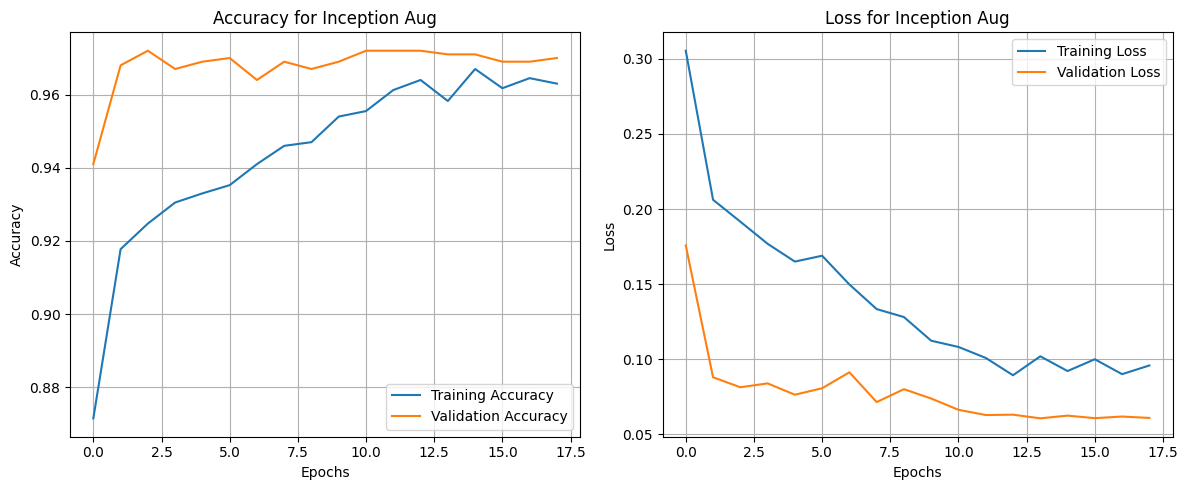


EXPERIMENT NAME                | TEST ACCURACY
--------------------------------------------------
Inception Aug                  | 97.80%



In [11]:
analyze_and_store_results("Inception Aug", hist_inc_aug, acc_inc_aug)

 ## Експеримент 6: ResNet50V2 (Deep Fine-Tuning)

 *   **Гіпотеза:** ResNet дуже глибока. Розморозимо більше блоків.

 *   **FT:** Старт розморозки з `conv4_block1_preact_bn`.

In [12]:
hist_res_deep, acc_res_deep = run_experiment(
    name="Exp 6: ResNet50V2 Deep FT",
    base_model_class=ResNet50V2,
    target_size=(150, 150),
    preprocess_func=res_prep,
    dropout_rate=0.2,
    unfreeze_from_layer_name='conv4_block1_preact_bn',
    optimizer_type='rmsprop' # Повернемо RMSprop для порівняння стабільності
)

analyze_and_store_results("ResNet Deep", hist_res_deep, acc_res_deep)


STARTING EXPERIMENT: Exp 6: ResNet50V2 Deep FT
Found 4000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
--- Phase 1: Training Head (Exp 6: ResNet50V2 Deep FT) ---
Epoch 1/6


KeyboardInterrupt: 

 ## Порівняння результатів та візуалізація

In [ ]:
def plot_final_comparison(results_list):
    """Візуалізує порівняння всіх збережених експериментів."""
    if not results_list:
        print("No results to compare.")
        return

    plt.figure(figsize=(20, 10))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    for res in results_list:
        plt.plot(res['history'].history['val_accuracy'], label=res['title'])
    plt.title('Final Validation Accuracy Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss Plot
    plt.subplot(1, 2, 2)
    for res in results_list:
        plt.plot(res['history'].history['val_loss'], label=res['title'])
    plt.title('Final Validation Loss Comparison')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    plt.show()

# Запуск фінального порівняння
print("\n" + "="*55)
print("FINAL SUMMARY OF ALL EXPERIMENTS".center(55))
print("="*55)

plot_final_comparison(experiment_results)

# Підсумкова таблиця
print("\n" + "="*50)
print(f"{'EXPERIMENT NAME':<30} | {'TEST ACCURACY':<10}")
print("-" * 50)
# Сортуємо результати для кращої читабельності
sorted_results = sorted(experiment_results, key=lambda x: x['accuracy'], reverse=True)
for res in sorted_results:
    print(f"{res['title']:<30} | {res['accuracy']*100:.2f}%")
print("="*50)

NameError: name 'hist_vgg_shallow' is not defined

 # Аналіз результатів



 ### 1. Вплив глибини розморожування (Deep vs Shallow FT)

 *   **VGG16:** Порівнюючи Exp 1 та Exp 2. Чи дало розморожування 4-го блоку приріст точності? Зазвичай для VGG це допомагає, оскільки вона має простішу ієрархію ознак.

 *   **ResNet:** Порівнюючи Exp 5 та Exp 6. Чи не призвело занадто глибоке розморожування до "catastrophic forgetting" (погіршення результатів) або перенавчання?



 ### 2. Аугментація

 *   В Exp 4 ми використали сильну аугментацію для InceptionV3. Чи стала валідаційна точність більш плавною? Чи зменшився розрив між train та val loss (overfitting)?



 ### 3. Порівняння архітектур

 *   В Lab 08 VGG16 відставала. Чи вдалося за допомогою Fine Tuning наблизити її до ResNet/Inception?

 *   Яка модель виявилася найшвидшою у навчанні і найстабільнішою?



 ### 4. Оптимізатори

 *   Як показав себе Adam (Exp 5) порівняно з RMSprop? Чи швидше він досяг плато?